In [1]:
import src.R_BP_james as rbp
import matplotlib.pyplot as plt
import numpy as np

from src.time_varying_vine_copula import cauchy_prior

Generate bimodal gaussian data


(array([ 2.,  2.,  5.,  8.,  8., 15., 12., 16., 19., 24., 26., 35., 39.,
        30., 25., 11., 16., 10.,  8., 10.,  8., 11., 16., 18., 21., 30.,
        24., 25., 39., 40., 46., 41., 42., 32., 45., 37., 40., 36., 27.,
        23., 19., 22.,  7., 10.,  9.,  0.,  5.,  4.,  0.,  2.]),
 array([-4.86705495, -4.62542679, -4.38379862, -4.14217045, -3.90054228,
        -3.65891411, -3.41728594, -3.17565778, -2.93402961, -2.69240144,
        -2.45077327, -2.2091451 , -1.96751694, -1.72588877, -1.4842606 ,
        -1.24263243, -1.00100426, -0.75937609, -0.51774793, -0.27611976,
        -0.03449159,  0.20713658,  0.44876475,  0.69039291,  0.93202108,
         1.17364925,  1.41527742,  1.65690559,  1.89853376,  2.14016192,
         2.38179009,  2.62341826,  2.86504643,  3.1066746 ,  3.34830276,
         3.58993093,  3.8315591 ,  4.07318727,  4.31481544,  4.55644361,
         4.79807177,  5.03969994,  5.28132811,  5.52295628,  5.76458445,
         6.00621261,  6.24784078,  6.48946895,  6.73109712,

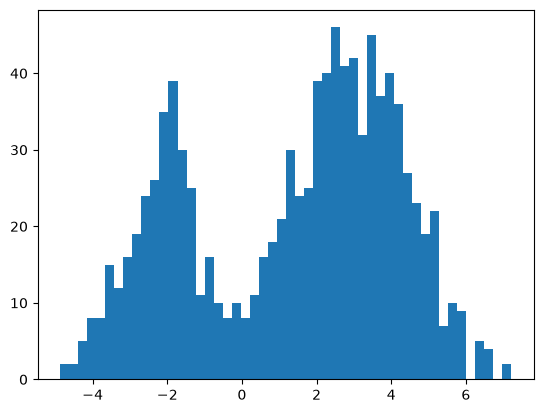

In [2]:
rng = np.random.default_rng(42)

proportions = np.array([0.3, 0.7])
means = np.array([-2.0, 3.0])
stds = np.array([1.0, 1.5])

n_samples = 1000
components = rng.choice(2, size=n_samples, p=proportions)
data = rng.normal(loc=means[components], scale=stds[components])

plt.hist(data, bins=50)

Fit a prior and an rbp process to that data

In [3]:
prior = cauchy_prior()
prior.fit(np.expand_dims(data, axis=1))

p_data, c_data = prior.eval(np.expand_dims(data, axis=1))

recursive = rbp.rbp_process(grid_size=5000)
recursive.fit(p_data, c_data)

Cauchy Locs = [np.float64(2.2556591680433593)]
Scales = [np.float64(1.720192985810447)]


Generate test data

In [4]:
rng = np.random.default_rng(1)

proportions = np.array([0.3, 0.7])
means = np.array([-2.0, 3.0])
stds = np.array([1.0, 1.5])

n_samples = 1000
components = rng.choice(2, size=n_samples, p=proportions)
test_data = rng.normal(loc=means[components], scale=stds[components])

Transform test data using prior and rbp, then estimate the inverse tranform.

[0.99700073]


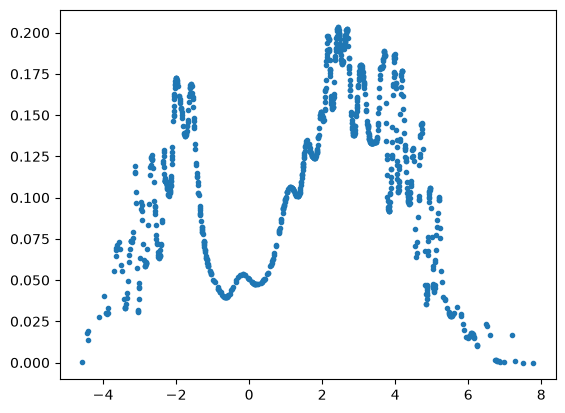

In [5]:
test_prior, test_prior_c = prior.eval(np.expand_dims(test_data, axis=1))

t_rbp_p, t_rbp_c = recursive.eval(test_prior, test_prior_c)
print(recursive.rhos)

plt.plot(test_data, t_rbp_p, '.')


Invert using the grid

In [6]:
inverted_est = recursive.estimate_inverse_cdf(t_rbp_c)
inv_prior_est = prior.ppf(inverted_est)

(1000,)


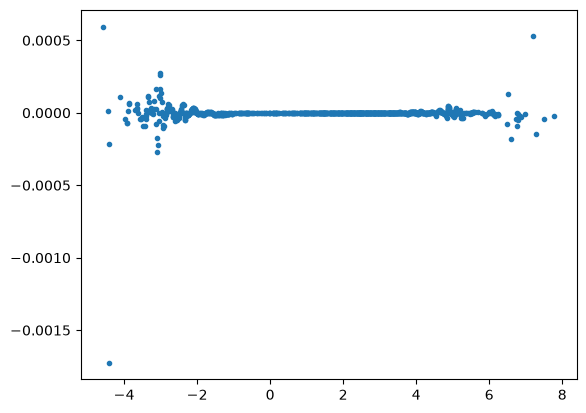

The mean residual is -1.204772809404675e-06 with standard deviation 6.626271988134851e-05


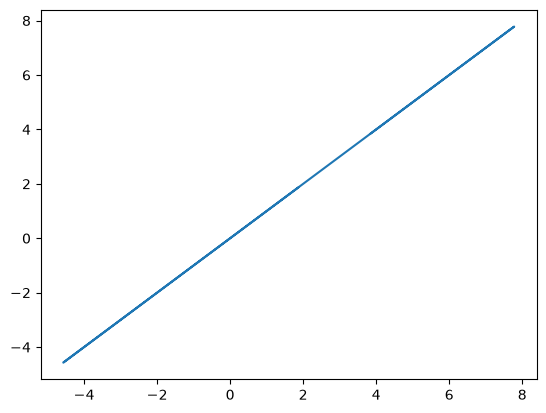

In [8]:
residuals_est = test_data-inv_prior_est[:,0]

plt.plot(test_data, residuals_est, '.')
plt.show()
plt.plot(test_data, inv_prior_est[:,0])

print(f"The mean residual is {np.mean(residuals_est)} with standard deviation {np.std(residuals_est)}")

Invert using recursive brentq

In [ ]:
inverted = recursive.inverse_cdf(t_rbp_c)
inv_prior = prior.ppf(inverted)

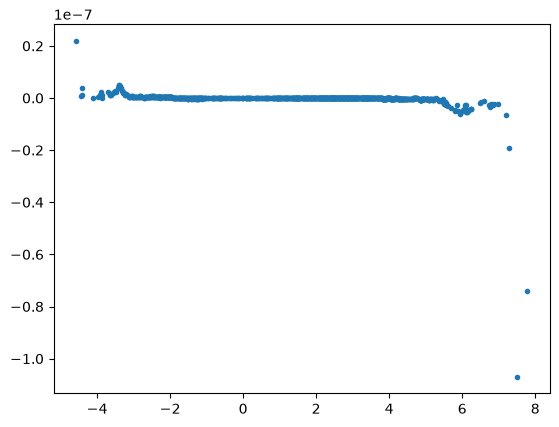

The mean residual is -2.507560670217401e-10 with standard deviation 4.31060937158373e-09


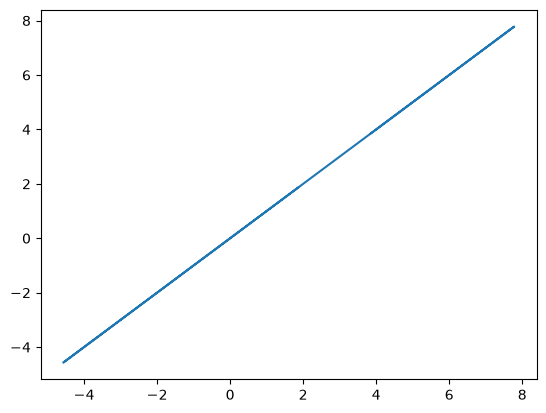

In [ ]:

residuals = test_data-inv_prior[:,0]

plt.plot(test_data, residuals, '.')
plt.show()
plt.plot(test_data, inv_prior[:,0])

print(f"The mean residual is {np.mean(residuals)} with standard deviation {np.std(residuals)}")
